# LSTM + SArimax grid search




Epoch 1/20

89/89 - 3s - loss: 0.0134 - val_loss: 0.0044 - 3s/epoch - 35ms/step
Epoch 2/20
89/89 - 1s - loss: 0.0030 - val_loss: 0.0044 - 529ms/epoch - 6ms/step
Epoch 3/20
89/89 - 0s - loss: 0.0025 - val_loss: 0.0033 - 497ms/epoch - 6ms/step
Epoch 4/20
89/89 - 1s - loss: 0.0024 - val_loss: 0.0031 - 518ms/epoch - 6ms/step
Epoch 5/20
89/89 - 1s - loss: 0.0019 - val_loss: 0.0028 - 516ms/epoch - 6ms/step
Epoch 6/20
89/89 - 1s - loss: 0.0017 - val_loss: 0.0023 - 505ms/epoch - 6ms/step
Epoch 7/20
89/89 - 0s - loss: 0.0017 - val_loss: 0.0023 - 472ms/epoch - 5ms/step
Epoch 8/20
89/89 - 1s - loss: 0.0015 - val_loss: 0.0022 - 546ms/epoch - 6ms/step
Epoch 9/20
89/89 - 0s - loss: 0.0014 - val_loss: 0.0021 - 497ms/epoch - 6ms/step
Epoch 10/20
89/89 - 1s - loss: 0.0014 - val_loss: 0.0020 - 651ms/epoch - 7ms/step
Epoch 11/20
89/89 - 0s - loss: 0.0013 - val_loss: 0.0021 - 488ms/epoch - 5ms/step
Epoch 12/20
89/89 - 0s - loss: 0.0013 - val_loss: 0.0018 - 495ms/epoch - 6ms/step
Epoch 13/20
89/89 - 0s 

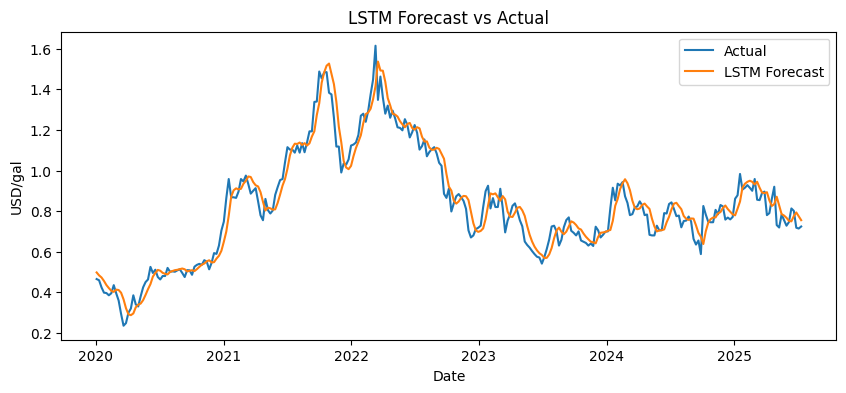

✔️ LSTM model complete.


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
y = df['lpg_price'].resample('W-FRI').last().dropna().to_frame()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(y)

def create_sequences(data, lookback=12):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        Y.append(data[i])
    return np.array(X), np.array(Y)

lookback = 12
X, Y = create_sequences(scaled, lookback)

split = np.where(y.index >= '2020-01-01')[0][0] - lookback
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

#LSTM
model = Sequential([
    LSTM(32, input_shape=(lookback, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

#Train
history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, Y_test),
    verbose=2
)

# Forecast
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
actual = y.values[lookback+split:]

# Metrics
mae = mean_absolute_error(actual, pred)
mape = mean_absolute_percentage_error(actual, pred) * 100
print(f"LSTM MAE: {mae:.3f} USD/gal, MAPE: {mape:.2f}%")

pred_index = y.index[lookback+split:]
pred_df = pd.DataFrame({'forecast': pred.flatten()}, index=pred_index)
pred_df.to_csv('lpg_lstm_predictions.csv')
print("✅ Saved LSTM predictions to lpg_lstm_predictions.csv")

# Plot
plt.figure(figsize=(10,4))
plt.plot(pred_index, actual, label='Actual')
plt.plot(pred_index, pred, label='LSTM Forecast')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.show()

print("✔️ LSTM model complete.")


Starting SARIMAX grid search...
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4017.8
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4495.3
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.6
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4466.9
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4016.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4122.6
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4483.4
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4019.9
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4514.2
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.7
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4510.8
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4015.0
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.3
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.4
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=

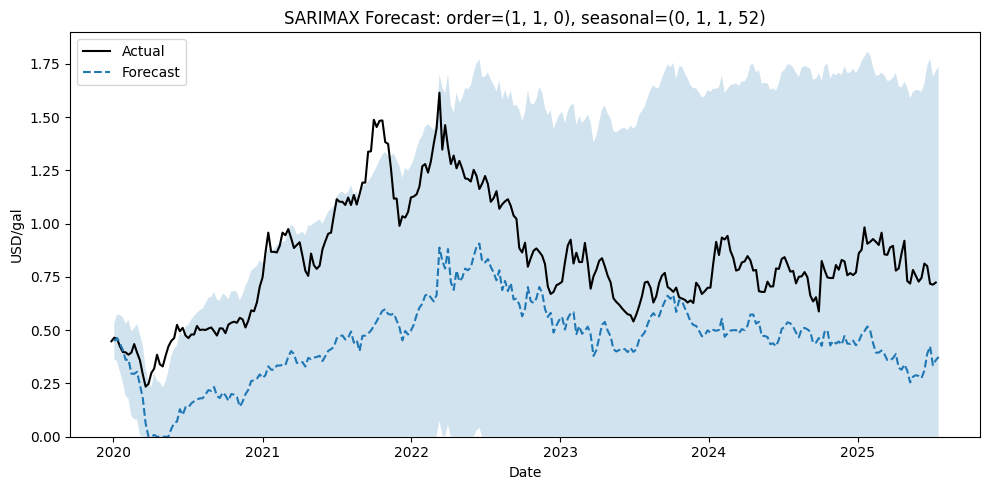

✔️ Grid search and forecast complete.


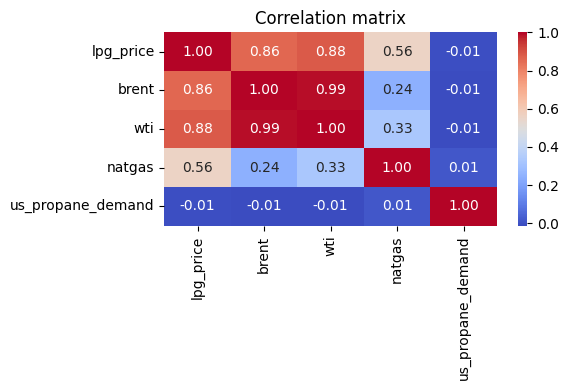

✔️  Exploration complete — scroll above to inspect the plots.


In [1]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py to generate lpg_dataset.csv first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)

# Weekly data (Friday)
y = df['lpg_price'].resample('W-FRI').last().dropna()
exog = df[['brent', 'wti']].resample('W-FRI').last().ffill()

data = pd.concat([y, exog], axis=1).dropna()

# Split into train / validation
train_end = '2019-12-27'
train = data.loc[:train_end]
valid = data.loc[train_end:]
train_y, train_ex = train['lpg_price'], train[['brent', 'wti']]
valid_y, valid_ex = valid['lpg_price'], valid[['brent', 'wti']]

# Grid search SARIMAX parameters
d = D = 1
s = 52
best_aic = np.inf
best_params = None
print("Starting SARIMAX grid search...")
for p in [0, 1]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    model = SARIMAX(
                        train_y,
                        exog=train_ex,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    res = model.fit(disp=False)
                    aic = res.aic
                    print(f"Tested (p,d,q)=({p},{d},{q}) x (P,D,Q,s)=({P},{D},{Q},{s}) -> AIC={aic:.1f}")
                    if aic < best_aic:
                        best_aic = aic
                        best_params = ((p, d, q), (P, D, Q, s))
                except Exception:
                    continue

if best_params is None:
    raise RuntimeError("Grid search failed to fit any SARIMAX models.")

order, seasonal = best_params
print(f"\nBest SARIMAX order={order}, seasonal_order={seasonal}, AIC={best_aic:.1f}\n")

best_model = SARIMAX(
    train_y,
    exog=train_ex,
    order=order,
    seasonal_order=seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
best_res = best_model.fit(disp=False)
forecast = best_res.get_forecast(steps=len(valid_y), exog=valid_ex)
fc = forecast.predicted_mean
ci = forecast.conf_int()

# Enforce non-negative forecasts
fc = fc.clip(lower=0.0)
ci_lower = ci.iloc[:, 0].clip(lower=0.0)
ci_upper = ci.iloc[:, 1].clip(lower=0.0)

# Save SARIMAX predictions for ensemble
pred_df = pd.DataFrame({'forecast': fc}, index=fc.index)
pred_df.to_csv('lpg_sarimax_predictions.csv')
print("✅ Saved SARIMAX predictions to lpg_sarimax_predictions.csv")

mae = mean_absolute_error(valid_y, fc)
mape = mean_absolute_percentage_error(valid_y, fc) * 100
print(f"Validation MAE:  {mae:.3f} USD/gal")
print(f"Validation MAPE: {mape:.2f} %")

plt.figure(figsize=(10, 5))
plt.plot(train_y.index, train_y, label='Train')
plt.plot(valid_y.index, valid_y, label='Actual', color='k')
plt.plot(fc.index, fc, label='Forecast', linestyle='--')
plt.fill_between(fc.index, ci_lower, ci_upper, alpha=0.2)
plt.title(f"SARIMAX Forecast: order={order}, seasonal={seasonal}")
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Grid search and forecast complete.")
# 4. Correlation heatmap
import numpy as np
import seaborn as sns 
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

print("✔️  Exploration complete — scroll above to inspect the plots.")


Individual model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
Using inverse-MAE weights: {'sarimax': 0.12232695063783776, 'lstm': 0.8776730493621622}
Ensemble MAE : 0.061 USD/gal
Ensemble MAPE: 7.67 %


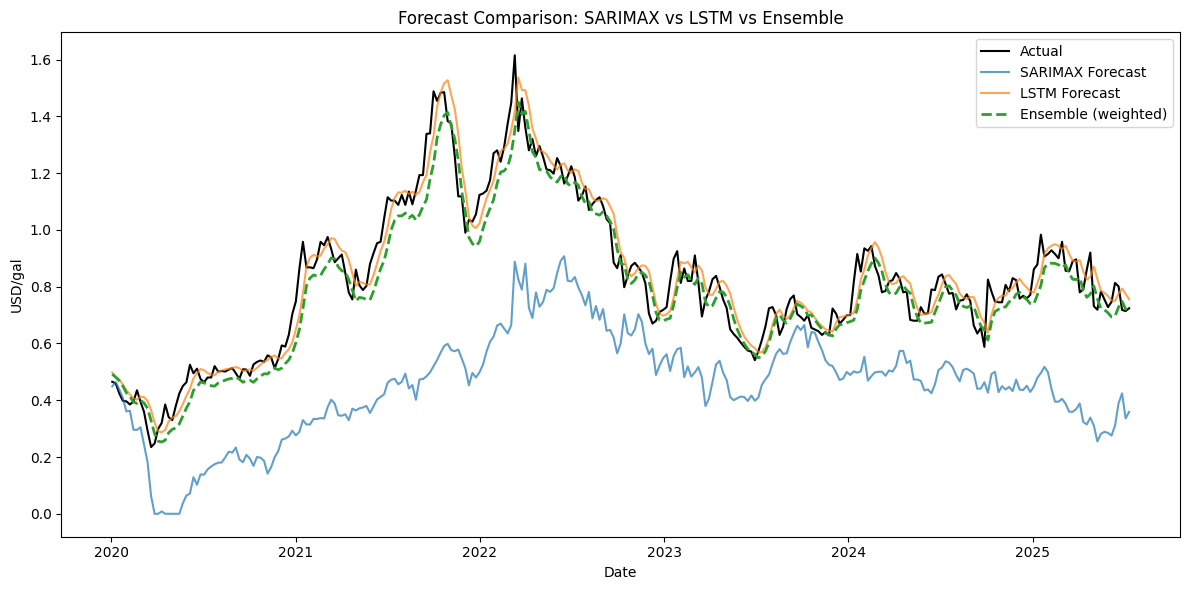

✔️ Ensemble evaluation complete.


In [2]:
"""
LPG Forecasting · Model Ensemble
"""
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from pathlib import Path

sarimax = pd.read_csv(
    "lpg_sarimax_predictions.csv", index_col=0, parse_dates=True
).rename(columns={'forecast':'sarimax'})
lstm = pd.read_csv(
    "lpg_lstm_predictions.csv",   index_col=0, parse_dates=True
).rename(columns={'forecast':'lstm'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

ensemble_df = pd.concat([
    actual.rename('lpg_price'),
    sarimax['sarimax'],
    lstm['lstm']
], axis=1, join='inner').dropna()

metrics = {}
for model in ['sarimax','lstm']:
    mae = mean_absolute_error(
        ensemble_df['lpg_price'], ensemble_df[model]
    )
    mape = mean_absolute_percentage_error(
        ensemble_df['lpg_price'], ensemble_df[model]
    ) * 100
    metrics[model] = {'MAE': mae, 'MAPE': mape}

metrics_df = pd.DataFrame(metrics).T
print("Individual model performance (2020–present):")
print(metrics_df)

#  Compute inverse-error weights 
errors = metrics_df['MAE'].to_dict()
inv = {m: 1/e if e>0 else 0 for m,e in errors.items()}
total = sum(inv.values())
weights = {m: inv[m]/total for m in inv}
print(f"Using inverse-MAE weights: {weights}")

#ensemble forecast and evaluate
ensemble_df['ensemble'] = (
    ensemble_df['sarimax'] * weights['sarimax'] +
    ensemble_df['lstm']    * weights['lstm']
)
# Evaluate ensemble
mae = mean_absolute_error(
    ensemble_df['lpg_price'], ensemble_df['ensemble']
)
mape = mean_absolute_percentage_error(
    ensemble_df['lpg_price'], ensemble_df['ensemble']
) * 100
print(f"Ensemble MAE : {mae:.3f} USD/gal")
print(f"Ensemble MAPE: {mape:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(ensemble_df.index, ensemble_df['lpg_price'], label='Actual', color='k')
plt.plot(ensemble_df.index, ensemble_df['sarimax'], label='SARIMAX Forecast', alpha=0.7)
plt.plot(ensemble_df.index, ensemble_df['lstm'], label='LSTM Forecast', alpha=0.7)
plt.plot(ensemble_df.index, ensemble_df['ensemble'],
         label='Ensemble (weighted)', linestyle='--', linewidth=2)
plt.title('Forecast Comparison: SARIMAX vs LSTM vs Ensemble')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Ensemble evaluation complete.")


# adjusted weights grid search over alpha

Individual model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
Optimal weight for LSTM (α): 0.98  (MAE: 0.051)
Ensemble MAE : 0.051 USD/gal
Ensemble MAPE: 6.60 %


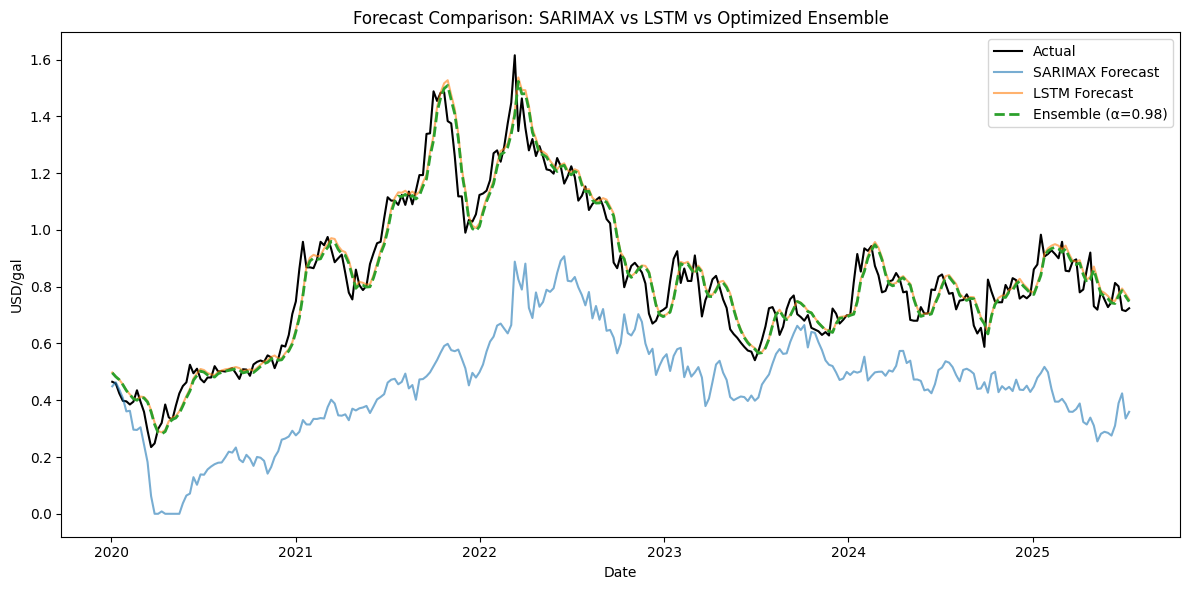

✔️ Optimized ensemble evaluation complete.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from pathlib import Path

darimax_file = Path("lpg_sarimax_predictions.csv")
lstm_file   = Path("lpg_lstm_predictions.csv")

sarimax = pd.read_csv(darimax_file, index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm   = pd.read_csv(lstm_file,   index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

# Align series with inner join
ensemble_df = pd.concat([
    actual.rename('lpg_price'),
    sarimax['sarimax'],
    lstm['lstm']
], axis=1, join='inner').dropna()

metrics = {}
for model in ['sarimax','lstm']:
    mae = mean_absolute_error(ensemble_df['lpg_price'], ensemble_df[model])
    mape = mean_absolute_percentage_error(ensemble_df['lpg_price'], ensemble_df[model]) * 100
    metrics[model] = {'MAE': mae, 'MAPE': mape}
metrics_df = pd.DataFrame(metrics).T
print("Individual model performance (2020–present):")
print(metrics_df)

# Grid-search ensemble weight α,0
alphas = np.linspace(0,1,51)
best_mae = np.inf
best_alpha = None
for alpha in alphas:
    ensemble_pred = alpha * ensemble_df['lstm'] + (1-alpha) * ensemble_df['sarimax']
    mae = mean_absolute_error(ensemble_df['lpg_price'], ensemble_pred)
    if mae < best_mae:
        best_mae = mae
        best_alpha = alpha
print(f"Optimal weight for LSTM (α): {best_alpha:.2f}  (MAE: {best_mae:.3f})")

ensemble_df['ensemble'] = best_alpha * ensemble_df['lstm'] + (1-best_alpha) * ensemble_df['sarimax']
mae_en = mean_absolute_error(ensemble_df['lpg_price'], ensemble_df['ensemble'])
mape_en = mean_absolute_percentage_error(ensemble_df['lpg_price'], ensemble_df['ensemble']) * 100
print(f"Ensemble MAE : {mae_en:.3f} USD/gal")
print(f"Ensemble MAPE: {mape_en:.2f} %")

# 7. Plot results -----------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(ensemble_df.index, ensemble_df['lpg_price'], label='Actual', color='k')
plt.plot(ensemble_df.index, ensemble_df['sarimax'], label='SARIMAX Forecast', alpha=0.6)
plt.plot(ensemble_df.index, ensemble_df['lstm'], label='LSTM Forecast', alpha=0.6)
plt.plot(ensemble_df.index, ensemble_df['ensemble'], label=f'Ensemble (α={best_alpha:.2f})', linestyle='--', linewidth=2)
plt.title('Forecast Comparison: SARIMAX vs LSTM vs Optimized Ensemble')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Optimized ensemble evaluation complete.")


# Two-stage grid-search ensemble weight α

Individual model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
Coarse optimal α: 0.980 (MAE: 0.051)
Refined optimal α: 0.9756 (MAE: 0.051)
Ensemble MAE : 0.051 USD/gal
Ensemble MAPE: 6.60 %


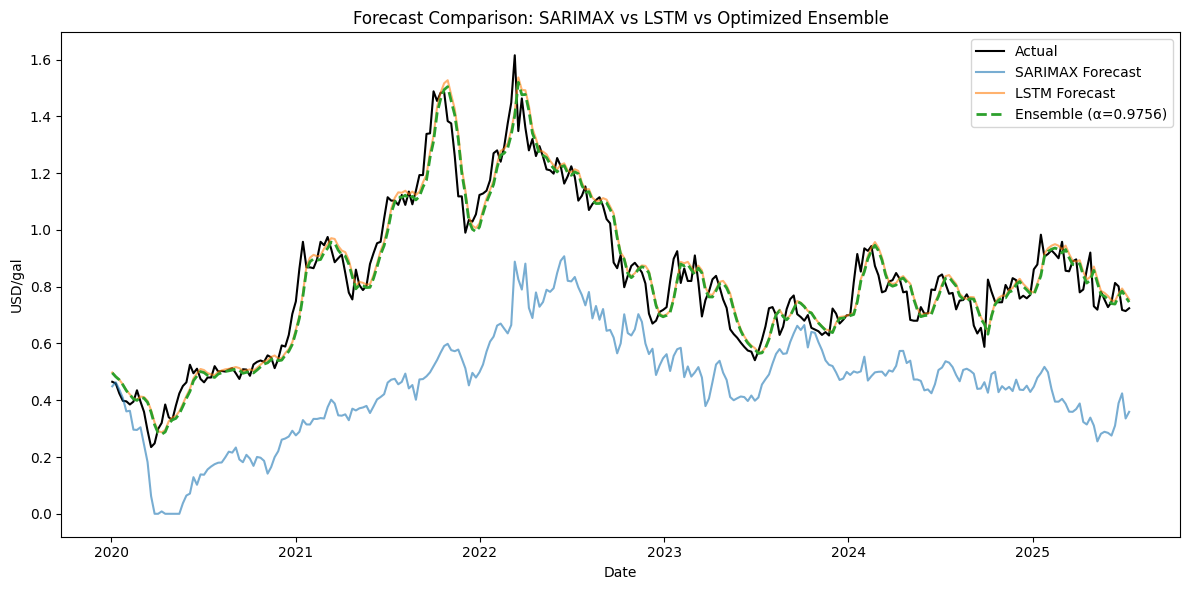

✔️ Optimized ensemble evaluation complete.


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from pathlib import Path

darimax_file = Path("lpg_sarimax_predictions.csv")
sarimax_file = darimax_file
lstm_file   = Path("lpg_lstm_predictions.csv")

sarimax = pd.read_csv(sarimax_file, index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(lstm_file, index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

ensemble_df = pd.concat([
    actual.rename('lpg_price'),
    sarimax['sarimax'],
    lstm['lstm']
], axis=1, join='inner').dropna()

metrics = {}
for model in ['sarimax','lstm']:
    mae = mean_absolute_error(ensemble_df['lpg_price'], ensemble_df[model])
    mape = mean_absolute_percentage_error(ensemble_df['lpg_price'], ensemble_df[model]) * 100
    metrics[model] = {'MAE': mae, 'MAPE': mape}
metrics_df = pd.DataFrame(metrics).T
print("Individual model performance (2020–present):")
print(metrics_df)

# Two-stage grid-search ensemble weight α
# Stage 1: coarse search over [0,1]
coarse_alphas = np.linspace(0, 1, 51)
best_mae = np.inf
best_alpha = None
for alpha in coarse_alphas:
    ens_pred = alpha * ensemble_df['lstm'] + (1 - alpha) * ensemble_df['sarimax']
    mae = mean_absolute_error(ensemble_df['lpg_price'], ens_pred)
    if mae < best_mae:
        best_mae = mae
        best_alpha = alpha
print(f"Coarse optimal α: {best_alpha:.3f} (MAE: {best_mae:.3f})")

# Stage 2: fine search around coarse best (± step)
step = coarse_alphas[1] - coarse_alphas[0]
low = max(0, best_alpha - step)
high = min(1, best_alpha + step)
fine_alphas = np.linspace(low, high, 201)
best_mae_fine = np.inf
best_alpha_fine = None
for alpha in fine_alphas:
    ens_pred = alpha * ensemble_df['lstm'] + (1 - alpha) * ensemble_df['sarimax']
    mae = mean_absolute_error(ensemble_df['lpg_price'], ens_pred)
    if mae < best_mae_fine:
        best_mae_fine = mae
        best_alpha_fine = alpha
print(f"Refined optimal α: {best_alpha_fine:.4f} (MAE: {best_mae_fine:.3f})")

best_alpha = best_alpha_fine
ensemble_df['ensemble'] = best_alpha * ensemble_df['lstm'] + (1 - best_alpha) * ensemble_df['sarimax']
mae_en = mean_absolute_error(ensemble_df['lpg_price'], ensemble_df['ensemble'])
mape_en = mean_absolute_percentage_error(ensemble_df['lpg_price'], ensemble_df['ensemble']) * 100
print(f"Ensemble MAE : {mae_en:.3f} USD/gal")
print(f"Ensemble MAPE: {mape_en:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(ensemble_df.index, ensemble_df['lpg_price'], label='Actual', color='k')
plt.plot(ensemble_df.index, ensemble_df['sarimax'], label='SARIMAX Forecast', alpha=0.6)
plt.plot(ensemble_df.index, ensemble_df['lstm'], label='LSTM Forecast', alpha=0.6)
plt.plot(ensemble_df.index, ensemble_df['ensemble'], label=f'Ensemble (α={best_alpha:.4f})', linestyle='--', linewidth=2)
plt.title('Forecast Comparison: SARIMAX vs LSTM vs Optimized Ensemble')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Optimized ensemble evaluation complete.")


Train weeks: 1434, Validation weeks: 290


C:\Users\Ryan Arrt7\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                          lpg_price   No. Observations:                 1434
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                2248.581
Date:                            Thu, 24 Jul 2025   AIC                          -4483.162
Time:                                    04:32:19   BIC                          -4446.827
Sample:                                07-10-1992   HQIC                         -4469.543
                                     - 12-27-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
brent          0.0065      0.001      7.974      0.000       0.005       0.008
wti            0.0031      0.001   

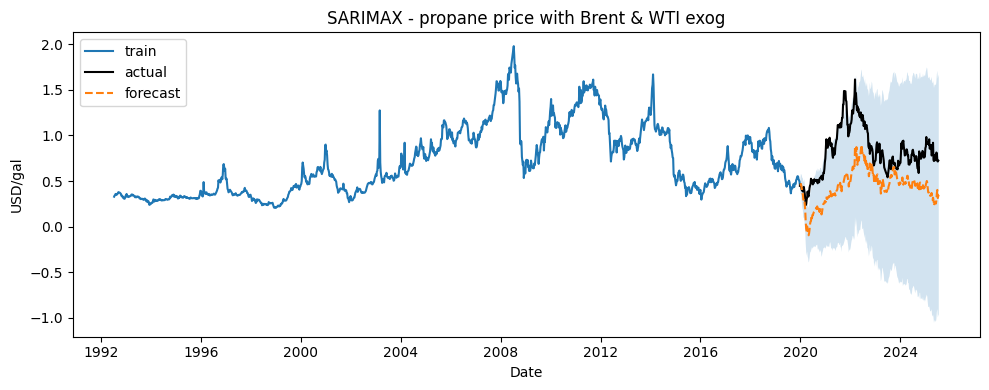

✔️  SARIMAX complete — inspect plot & metrics above.


NameError: name 'acorr_ljungbox' is not defined

In [3]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Run the collector script first to create lpg_dataset.csv")


df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
# target series
y = df["lpg_price"].dropna()
# exogenous: Brent, WTI
exog = df[["brent", "wti"]].ffill().dropna()

y_w = y.resample("W-FRI").last()
exog_w = exog.resample("W-FRI").last()

data = pd.concat([y_w, exog_w], axis=1).dropna()

y_w, exog_w = data["lpg_price"], data[["brent", "wti"]]

train_end = "2019-12-27"
train_y = y_w.loc[:train_end]
train_ex = exog_w.loc[:train_end]
valid_y = y_w.loc[train_end:]
valid_ex = exog_w.loc[train_end:]

print(f"Train weeks: {len(train_y)}, Validation weeks: {len(valid_y)}")

order = (1, 1, 1)
seasonal_order = (1, 1, 1, 52)
model = SARIMAX(
    train_y,
    exog=train_ex,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print(results.summary())

steps = len(valid_y)
fc = results.get_forecast(steps=steps, exog=valid_ex)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

mae = mean_absolute_error(valid_y, fc_mean)
mape = mean_absolute_percentage_error(valid_y, fc_mean) * 100
print(f"\nSARIMAX MAE  : {mae:.3f} USD/gal")
print(f"SARIMAX MAPE : {mape:.2f} %")

plt.figure(figsize=(10,4))
plt.plot(train_y.index, train_y, label="train")
plt.plot(valid_y.index, valid_y, label="actual", color="k")
plt.plot(fc_mean.index, fc_mean, label="forecast", linestyle="--")
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2)
plt.title("SARIMAX - propane price with Brent & WTI exog")
plt.xlabel("Date")
plt.ylabel("USD/gal")
plt.legend()
plt.tight_layout()
plt.show()

print("✔️  SARIMAX complete — inspect plot & metrics above.")

from statsmodels.tsa.statespace.sarimax import SARIMAXResults  
import joblib

SAVE_DIR   = Path('.')
MODEL_PATH = SAVE_DIR / 'lpg_sarimax_model.pkl'   
PRED_PATH  = SAVE_DIR / 'lpg_sarimax_predictions.csv'  
RESID_PATH = SAVE_DIR / 'lpg_sarimax_residuals.csv'

results.save(MODEL_PATH)
pd.DataFrame({'forecast': fc_mean}, index=fc_mean.index).to_csv(PRED_PATH)

residuals = results.resid.dropna()
residuals.to_csv(RESID_PATH, header=['residual'])

lb = acorr_ljungbox(residuals, lags=[12, 24, 52], return_df=True)
print('Residual Ljung–Box p-values (lags 12/24/52):')
print(lb['lb_pvalue'].values)